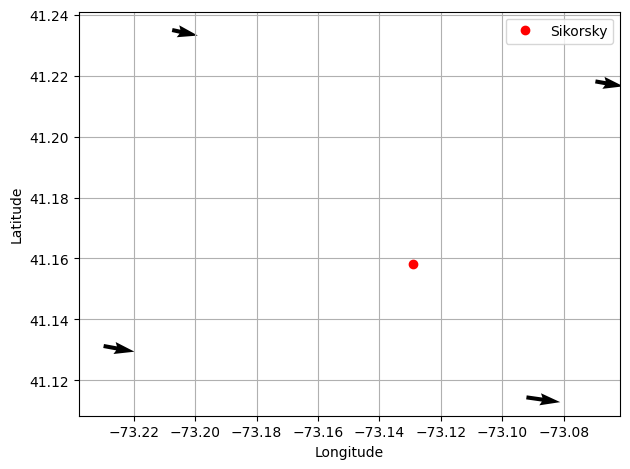

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset('netcdf_files/nam_20250601_f001.nc')

plt.quiver(ds.longitude, ds.latitude, ds.u10, ds.v10)
plt.plot(-73.1289, 41.1583, 'ro', label='Sikorsky')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('Sikorsky_fcst.csv')

# Compute WSPD in m/s
df['WSPD'] = np.sqrt(df['u10']**2 + df['v10']**2)
# Compute WDIR in degrees, from true north
df['WDIR'] = (np.degrees(np.arctan2(-df['u10'], -df['v10'])) + 360) % 360

# Compute updated wind components
alpha = -13
theta = -alpha * np.pi / 180
df['u_e'] = df['u10'] * np.cos(theta) + df['v10'] * np.sin(theta)
df['u_n'] = -df['u10'] * np.sin(theta) + df['v10'] * np.cos(theta)

# df.to_csv('Sikorsky_fcst_new.csv', index=False)
df.head()

,TmStamp,u10,v10,WSPD,WDIR,u_e,u_n
0,2024-07-01 00:00:00,0.889252,-2.443201,2.60,340.0,0.316860,-2.580620
1,2024-07-01 01:00:00,2.050000,-3.550704,4.10,330.0,1.198724,-3.920849
2,2024-07-01 02:00:00,1.671248,-1.991716,2.60,320.0,1.180375,-2.316617
3,2024-07-01 03:00:00,-0.000000,-0.250000,0.25,0.0,-0.056238,-0.243593
4,2024-07-01 04:00:00,1.992642,-2.374738,3.10,320.0,1.407371,-2.762120
